In [1]:
import os
import h5py
import pywt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from typing import List, Tuple
from scipy.stats import entropy
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from utils import process_file, label_lab, experiment_based_classification
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler

### Loading data

In [2]:
## Load stimuli
file = "../data/1D_ind_sin_stimuli_responses/MR-0644_flashes_sinusoidals_stimuli.h5"
ts = []
with h5py.File(file, "r") as f:
    for key in f.keys():
        ts.append(f[key]["data"][:])

## Load responses
path = '../data/1D_ind_sin_stimuli_responses/'
files = os.listdir(path)
file_names = [f for f in files if os.path.isfile(os.path.join(path, f))]
file_names = [f for f in file_names if "flashes_sinusoidals.h5" in f]

df = pd.DataFrame({"H":[i for i in range(42)]})
for file in file_names:
    means = process_file(path+file)
    df[file[:-23]] = means
df = df.T
df = df.drop(index=["H"])
df

,0,1,2,3,4,5,6,7,8,9,...,32,33,34,35,36,37,38,39,40,41
MR-0644,"[-0.00024676729420533507, -0.00048507447407271...","[-0.0006610605025799696, 0.0002234065493280247...","[0.00047592569285939836, -0.000530924757832139...","[-5.3423853087005754e-05, -0.00146436379841268...","[-0.0010618159835306899, -0.003156465951578687...","[0.0001386449459426971, 0.00101067750455003, 0...","[-0.00037143290062919876, -0.00056081006722302...","[-0.00018394903511259546, -0.00076261754175243...","[-0.0004901587452150039, 0.0018185057693241467...","[-0.000865276124238152, -0.0001888439242439524...",...,"[-7.761409121477668e-05, -7.546264171878952e-0...","[-0.00042226766378839484, -0.00283181191946262...","[-0.0016318470793212085, -0.000882041280572446...","[2.877464240455598e-05, -0.0015462694741864259...","[0.0004820387368268984, -0.0001826679410438243...","[-0.0005555670988332548, -0.001132074288285714...","[0.0009005020811006079, 0.0012583347011023277,...","[0.0012417380482981234, 0.0029780678040637817,...","[0.00019115189299288073, 0.0019884939687984256...","[-2.5003134030896775e-06, -0.00051244175582721..."
MR-0645,"[-0.001146234522975336, -0.0023990090244361212...","[0.00040672187309684143, 0.0014145688235586659...","[-5.943996647582644e-05, -0.002808344134891233...","[2.7601688379250987e-05, 0.0008624702737431682...","[0.0006293816788908994, 0.0020958210803971836,...","[0.0003844487252471017, 0.001039504751568589, ...","[0.0002805362403708936, 0.0009476527460949506,...","[-0.000500124188629352, -0.0002437684763372750...","[-0.00013589464337917403, 0.001448603595199884...","[0.0014220731444664061, 0.0024950489834511492,...",...,"[-0.0010780921816669615, -0.003971623117227117...","[-0.0007284874528054402, -0.004151218345633532...","[0.0006726330235417125, 0.0002685823551740927,...","[-0.0009514022311126284, -0.003550269846939104...","[-0.000710307977694073, -0.0017517794513288256...","[0.0007122477221231744, -0.0012816145281151533...","[-0.0006007470161402746, 0.0003822014863958529...","[0.0005563269317171955, -0.0005884411652708502...","[-0.0002560205799583712, -0.000327758165181621...","[0.0025634895515709213, 0.0046689923796339825,..."
MR-0648,"[-0.0008756799065772364, -0.000190407038448596...","[-0.00044525770959157334, -0.00090734736236595...","[-0.0009605040476337299, -0.000969338086152490...","[0.0009972065827477125, 0.001259854559238781, ...","[0.0003810773434747262, -9.846598150194799e-06...","[-0.00032918597996784284, -0.00010969859517987...","[0.00044844808245280847, 0.0002541677526649027...","[-0.001581358193415284, 0.0006261790993631737,...","[-0.00043228397134817805, -0.00051274931169233...","[-0.0005529549745858818, 0.000662487170224476,...",...,"[0.00035397906583120993, 0.001397605418950568,...","[-0.0005732356541323691, 0.0007551968417835565...","[-0.0008816677353216328, -0.001323300987256707...","[0.0005628554330950336, 0.00023283087892509425...","[0.00017946405945166354, -0.000780860129594713...","[-0.0008033334950655833, -0.001778246460766482...","[0.0009459688190485966, 0.0015696985900978948,...","[0.0006260500768238199, 0.0001615885890063175,...","[0.0004031849719912496, -0.0011538865149443268...","[-0.0008257227453189434, 1.9591019594724974e-0..."
MR-0649,"[0.0006113718612664114, -0.0004099488682806194...","[-0.00036345613071687007, -0.00079381633266008...","[0.00041587625798359225, 0.0004339045196749006...","[-0.000470757498912155, -0.0004977080306818648...","[0.0005323030823376522, 0.0023796428582172186,...","[6.601965281790185e-05, -0.0002886537291881644...","[0.0010054606498580677, 0.0018139128710283172,...","[0.00047122926964059087, -4.760826866960795e-0...","[0.00011769274355226282, 0.0008426946795206849...","[0.001052400853975255, -0.0001039461058087415,...",...,"[-0.00012480129381858075, 0.000942934484990861...","[-8.775949351040706e-05, 0.0007341185689526748...","[-0.0009185183831878756, -0.003081486635313459...","[0.0009829865231020785, 0.001289716653828258, ...","[0.00024524121037949263, 6.701695370976096e-05..

In [3]:
## For ploting purposes we assign the corresponding labels and colors for mice
groups = {
    "5xFAD_3mF": ['MR-0644', 'MR-0645', 'MR-0648', 'MR-0649'],
    "5xFAD_3mM": ['MR-0661','MR-0663','MR-0667'],
    "5xFAD_6mF": ['MR-0659-t1', 'MR-0659-t2', 'MR-0676'],
    "5xFAD_6mM": ['MR-0657-t2', 'MR-0674', 'MR-0656'],
    "WT_3mF": ['MR-0677', 'MR-0678'],
    "WT_3mM": ['MR-0662', 'MR-0665', 'MR-0668', 'MR-0669'],
    "WT_6mF": ['MR-0679', 'MR-0680'],
    "WT_6mM": ['MR-0655', 'MR-0658', 'MR-0654-t1', 'MR-0654-t2', 'MR-0687-t1']
}

colors = {}
for key in groups.keys():
    for value in groups[key]:
        if "5xFAD_3m" in key:
            colors[value] = "r"
        elif "5xFAD_6m" in key:
            colors[value] = "b"
        elif "WT_3m" in key:
            colors[value] = "g"
        elif "WT_6m" in key:
            colors[value] = "m"
        else:
            colors[value] = "k"

for value in df.index:
    if value != "H":
        if value not in colors.keys():
            colors[value] = "k"

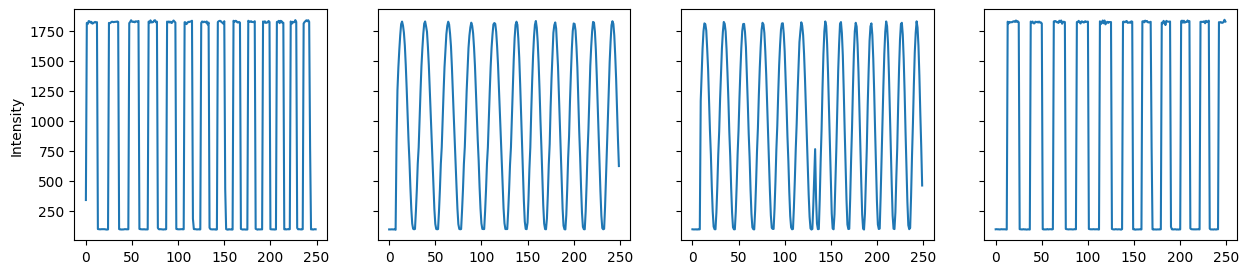

In [5]:
## few examples of the actual stimulus
fig, axs = plt.subplots(1,4,sharey=True,figsize=(15,3))
axs[0].plot(ts[0][:500:2])
axs[1].plot(ts[8][:500:2])
axs[2].plot(ts[9][:500:2])
axs[3].plot(ts[19][:500:2])
axs[0].set_ylabel("Intensity")
plt.show()

## wavelet analyses

In [10]:
wavelet_props = df.copy()
kl_stats = df.copy()
color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']
labels_sujetos = []
for ex in range(21):
    stimuli_profile = pywt.wavedec(ts[ex+1], wavelet='db2')
    stimuli_approx = stimuli_profile[0]
    stimuli_total_energy = np.sum(np.square(stimuli_approx))
    stimuli_details = [np.sum(np.square(stimuli_approx))]
    for level_dict in stimuli_profile[1:]:
        level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
        stimuli_total_energy += level_energy
        stimuli_details.append(level_energy)

    stimuli_proportions = [e / stimuli_total_energy for e in stimuli_details]

    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.abs(df.at[df.index[indice], ex])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            wavelet_props.at[df.index[indice], ex] = proportions
            kl_stats.at[df.index[indice], ex] = entropy(stimuli_proportions,proportions)
            if ex == 1:
                l = label_lab(df.index[indice],groups)
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')

entropy_stats = wavelet_props.copy()
for column in entropy_stats.columns:
    if column != "type":
        entropy_stats[column] =  wavelet_props[column].apply(entropy)

wavelet_props['type'] = labels_sujetos
entropy_stats['type'] = labels_sujetos
kl_stats['type'] = labels_sujetos

for column in entropy_stats.columns:
    if column != "type":
        wavelet_props[column] =  wavelet_props[column].apply(lambda x: x[3])

KeyboardInterrupt: 

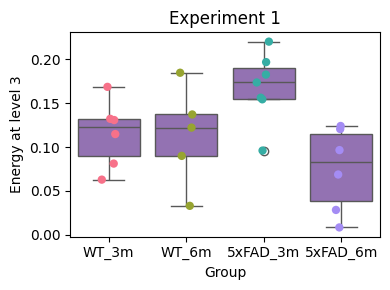

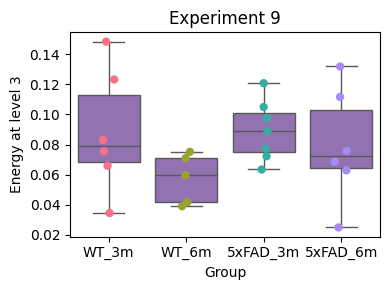

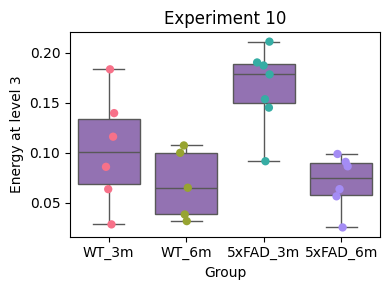

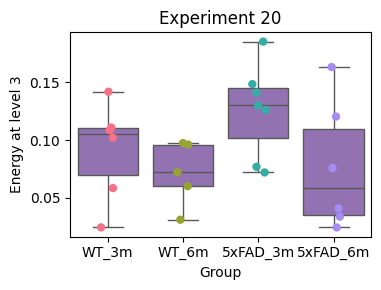

In [ ]:
for stimuli in [0,8,9,19]:
    plt.figure(figsize=(4,3))
    sns.stripplot(data=wavelet_props[wavelet_props['type']!='no class'], x='type', y=stimuli, jitter=True, size=6, palette='husl',hue='type')
    sns.boxplot(data=wavelet_props[wavelet_props['type']!='no class'], x='type', y=stimuli)
    plt.xlabel("Group")
    plt.ylabel("Energy at level 3")
    plt.title(f'Experiment {stimuli+1}')
    plt.tight_layout()
    plt.show()

In [ ]:
wavelet_props = wavelet_props[wavelet_props["type"] != "no class"]
print(wavelet_props['type'].value_counts())

type
5xFAD_3m    7
WT_3m       6
5xFAD_6m    6
WT_6m       5
Name: count, dtype: int64


In [ ]:
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(age))) for i in range(21)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]

for dataset in datasets:
    n_ex, X, y = dataset
    
    loo = LeaveOneOut()
    y_true, y_pred = [], []

    for train_idx, test_idx in loo.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Grid search with inner CV
        grid = GridSearchCV(
            pipeline,
            param_grid,
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        
        # Best pipeline from grid search
        best_clf = grid.best_estimator_
        
        # Predict
        prediction = best_clf.predict(X_test)
        
        y_true.append(y_test[0])
        y_pred.append(prediction[0])

    # Accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 50.00%
LOOCV Accuracy 1: 45.83%
LOOCV Accuracy 2: 54.17%
LOOCV Accuracy 3: 66.67%
LOOCV Accuracy 4: 50.00%
LOOCV Accuracy 5: 75.00%
LOOCV Accuracy 6: 33.33%
LOOCV Accuracy 7: 62.50%
LOOCV Accuracy 8: 66.67%
LOOCV Accuracy 9: 83.33%
LOOCV Accuracy 10: 58.33%
LOOCV Accuracy 11: 20.83%
LOOCV Accuracy 12: 70.83%
LOOCV Accuracy 13: 58.33%
LOOCV Accuracy 14: 79.17%
LOOCV Accuracy 15: 50.00%
LOOCV Accuracy 16: 70.83%
LOOCV Accuracy 17: 62.50%
LOOCV Accuracy 18: 62.50%
LOOCV Accuracy 19: 58.33%
LOOCV Accuracy 20: 58.33%


In [ ]:
experiment_based_classification(wavelet_props,age)

LOOCV Accuracy 0: 50.00%
LOOCV Accuracy 1: 45.83%
LOOCV Accuracy 2: 54.17%
LOOCV Accuracy 3: 66.67%
LOOCV Accuracy 4: 50.00%
LOOCV Accuracy 5: 75.00%
LOOCV Accuracy 6: 33.33%
LOOCV Accuracy 7: 62.50%
LOOCV Accuracy 8: 66.67%
LOOCV Accuracy 9: 83.33%
LOOCV Accuracy 10: 58.33%
LOOCV Accuracy 11: 20.83%
LOOCV Accuracy 12: 70.83%
LOOCV Accuracy 13: 58.33%
LOOCV Accuracy 14: 79.17%
LOOCV Accuracy 15: 50.00%
LOOCV Accuracy 16: 70.83%
LOOCV Accuracy 17: 62.50%
LOOCV Accuracy 18: 62.50%
LOOCV Accuracy 19: 58.33%
LOOCV Accuracy 20: 58.33%


{'0': 0.5,
 '1': 0.4583333333333333,
 '2': 0.5416666666666666,
 '3': 0.6666666666666666,
 '4': 0.5,
 '5': 0.75,
 '6': 0.3333333333333333,
 '7': 0.625,
 '8': 0.6666666666666666,
 '9': 0.8333333333333334,
 '10': 0.5833333333333334,
 '11': 0.20833333333333334,
 '12': 0.7083333333333334,
 '13': 0.5833333333333334,
 '14': 0.7916666666666666,
 '15': 0.5,
 '16': 0.7083333333333334,
 '17': 0.625,
 '18': 0.625,
 '19': 0.5833333333333334,
 '20': 0.5833333333333334}

In [ ]:
experiment_based_classification(entropy_stats,age)

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 42.31%
LOOCV Accuracy 1: 50.00%
LOOCV Accuracy 2: 65.38%
LOOCV Accuracy 3: 57.69%
LOOCV Accuracy 4: 65.38%
LOOCV Accuracy 5: 69.23%
LOOCV Accuracy 6: 23.08%
LOOCV Accuracy 7: 46.15%
LOOCV Accuracy 8: 65.38%
LOOCV Accuracy 9: 65.38%
LOOCV Accuracy 10: 30.77%
LOOCV Accuracy 11: 23.08%
LOOCV Accuracy 12: 34.62%
LOOCV Accuracy 13: 57.69%
LOOCV Accuracy 14: 57.69%
LOOCV Accuracy 15: 69.23%
LOOCV Accuracy 16: 57.69%
LOOCV Accuracy 17: 65.38%
LOOCV Accuracy 18: 57.69%
LOOCV Accuracy 19: 57.69%
LOOCV Accuracy 20: 26.92%


{'0': 0.4230769230769231,
 '1': 0.5,
 '2': 0.6538461538461539,
 '3': 0.5769230769230769,
 '4': 0.6538461538461539,
 '5': 0.6923076923076923,
 '6': 0.23076923076923078,
 '7': 0.46153846153846156,
 '8': 0.6538461538461539,
 '9': 0.6538461538461539,
 '10': 0.3076923076923077,
 '11': 0.23076923076923078,
 '12': 0.34615384615384615,
 '13': 0.5769230769230769,
 '14': 0.5769230769230769,
 '15': 0.6923076923076923,
 '16': 0.5769230769230769,
 '17': 0.6538461538461539,
 '18': 0.5769230769230769,
 '19': 0.5769230769230769,
 '20': 0.2692307692307692}

In [ ]:
experiment_based_classification(kl_stats,age)

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 42.31%
LOOCV Accuracy 1: 34.62%
LOOCV Accuracy 2: 53.85%
LOOCV Accuracy 3: 38.46%
LOOCV Accuracy 4: 57.69%
LOOCV Accuracy 5: 57.69%
LOOCV Accuracy 6: 61.54%
LOOCV Accuracy 7: 38.46%
LOOCV Accuracy 8: 50.00%
LOOCV Accuracy 9: 46.15%
LOOCV Accuracy 10: 61.54%
LOOCV Accuracy 11: 42.31%
LOOCV Accuracy 12: 53.85%
LOOCV Accuracy 13: 50.00%
LOOCV Accuracy 14: 73.08%
LOOCV Accuracy 15: 38.46%
LOOCV Accuracy 16: 53.85%
LOOCV Accuracy 17: 61.54%
LOOCV Accuracy 18: 57.69%
LOOCV Accuracy 19: 42.31%
LOOCV Accuracy 20: 61.54%


{'0': 0.4230769230769231,
 '1': 0.34615384615384615,
 '2': 0.5384615384615384,
 '3': 0.38461538461538464,
 '4': 0.5769230769230769,
 '5': 0.5769230769230769,
 '6': 0.6153846153846154,
 '7': 0.38461538461538464,
 '8': 0.5,
 '9': 0.46153846153846156,
 '10': 0.6153846153846154,
 '11': 0.4230769230769231,
 '12': 0.5384615384615384,
 '13': 0.5,
 '14': 0.7307692307692307,
 '15': 0.38461538461538464,
 '16': 0.5384615384615384,
 '17': 0.6153846153846154,
 '18': 0.5769230769230769,
 '19': 0.4230769230769231,
 '20': 0.6153846153846154}

In [ ]:
coactiv_stats = df.copy()

color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']#list(color_groups.keys())[:4]
labels_sujetos = []
for ex in range(21):
    #fig, ax = plt.subplots(1, figsize=(8, 5))
    
    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.multiply(ts[ex+1],np.abs(df.at[df.index[indice], ex])[:7500])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]  # start with approximation energy
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            coactiv_stats.at[df.index[indice], ex] = proportions
            if ex == 1:
                l = label_lab(df.index[indice],groups)
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')


coactiv_stats['type'] = labels_sujetos
coactiv_stats = coactiv_stats[coactiv_stats['type'] != 'no class']


for column in entropy_stats.columns:
    if column != "type":
        coactiv_stats[column] =  coactiv_stats[column].apply(lambda x: x[3])

experiment_based_classification(coactiv_stats,age)

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 58.33%
LOOCV Accuracy 1: 62.50%
LOOCV Accuracy 2: 62.50%
LOOCV Accuracy 3: 66.67%
LOOCV Accuracy 4: 54.17%
LOOCV Accuracy 5: 66.67%
LOOCV Accuracy 6: 45.83%
LOOCV Accuracy 7: 58.33%
LOOCV Accuracy 8: 50.00%
LOOCV Accuracy 9: 87.50%
LOOCV Accuracy 10: 70.83%
LOOCV Accuracy 11: 33.33%
LOOCV Accuracy 12: 87.50%
LOOCV Accuracy 13: 58.33%
LOOCV Accuracy 14: 75.00%
LOOCV Accuracy 15: 66.67%
LOOCV Accuracy 16: 62.50%
LOOCV Accuracy 17: 50.00%
LOOCV Accuracy 18: 50.00%
LOOCV Accuracy 19: 75.00%
LOOCV Accuracy 20: 70.83%


{'0': 0.5833333333333334,
 '1': 0.625,
 '2': 0.625,
 '3': 0.6666666666666666,
 '4': 0.5416666666666666,
 '5': 0.6666666666666666,
 '6': 0.4583333333333333,
 '7': 0.5833333333333334,
 '8': 0.5,
 '9': 0.875,
 '10': 0.7083333333333334,
 '11': 0.3333333333333333,
 '12': 0.875,
 '13': 0.5833333333333334,
 '14': 0.75,
 '15': 0.6666666666666666,
 '16': 0.625,
 '17': 0.5,
 '18': 0.5,
 '19': 0.75,
 '20': 0.7083333333333334}

| Experimento | Wavelet        | Entropy        | KL Div         | Co-Act         |
|-------------|----------------|----------------|----------------|----------------|
| 0           | 50.00%         | 42.31%         | 42.31%         | 58.33%         |
| 1           | 45.83%         | 50.00%         | 34.62%         | 62.50%         |
| 2           | 54.17%         | 65.38% (light) | 53.85%         | 62.50%         |
| 3           | 66.67% (light) | 57.69%         | 38.46%         | 66.67% (light) |
| 4           | 50.00%         | 65.38% (light) | 57.69%         | 54.17%         |
| 5           | 75.00% (green) | 69.23% (light) | 57.69%         | 66.67% (light) |
| 6           | 33.33%         | 23.08%         | 61.54%         | 45.83%         |
| 7           | 62.50%         | 46.15%         | 38.46%         | 58.33%         |
| 8           | 66.67% (light) | 65.38% (light) | 50.00%         | 50.00%         |
| 9           | 83.33% (green) | 65.38% (light) | 46.15%         | 87.50% (green) |
| 10          | 58.33%         | 30.77%         | 61.54%         | 70.83% (light) |
| 11          | 20.83%         | 23.08%         | 42.31%         | 33.33%         |
| 12          | 70.83% (light) | 34.62%         | 53.85%         | 87.50% (green) |
| 13          | 58.33%         | 57.69%         | 50.00%         | 58.33%         |
| 14          | 79.17% (green) | 57.69%         | 73.08% (light) | 75.00% (green) |
| 15          | 50.00%         | 69.23% (light) | 38.46%         | 66.67% (light) |
| 16          | 70.83% (light) | 57.69%         | 53.85%         | 62.50%         |
| 17          | 62.50%         | 65.38% (light) | 61.54%         | 50.00%         |
| 18          | 62.50%         | 57.69%         | 57.69%         | 50.00%         |
| 19          | 58.33%         | 57.69%         | 42.31%         | 75.00% (green) |
| 20          | 58.33%         | 26.92%         | 61.54%         | 70.83% (light) |


| Experimento | Wavelet | Entropy | KL Div | Co-Act |
|-------------|---------|---------|--------|--------|
| 0           | 50.00%  | 42.31%  | 42.31% | 58.33% |
| 1           | 45.83%  | 50.00%  | 34.62% | 62.50% |
| 2           | 54.17%  | <span style="background-color:#ccffcc">65.38%</span> | 53.85% | 62.50% |
| 3           | <span style="background-color:#ccffcc">66.67%</span> | 57.69% | 38.46% | <span style="background-color:#ccffcc">66.67%</span> |
| 4           | 50.00%  | <span style="background-color:#ccffcc">65.38%</span> | 57.69% | 54.17% |
| 5           | <span style="background-color:#66ff66">75.00%</span> | <span style="background-color:#ccffcc">69.23%</span> | 57.69% | <span style="background-color:#ccffcc">66.67%</span> |
| 6           | 33.33%  | 23.08%  | 61.54% | 45.83% |
| 7           | 62.50%  | 46.15%  | 38.46% | 58.33% |
| 8           | <span style="background-color:#ccffcc">66.67%</span> | <span style="background-color:#ccffcc">65.38%</span> | 50.00% | 50.00% |
| 9           | <span style="background-color:#66ff66">83.33%</span> | <span style="background-color:#ccffcc">65.38%</span> | 46.15% | <span style="background-color:#66ff66">87.50%</span> |
| 10          | 58.33%  | 30.77%  | 61.54% | <span style="background-color:#ccffcc">70.83%</span> |
| 11          | 20.83%  | 23.08%  | 42.31% | 33.33% |
| 12          | <span style="background-color:#ccffcc">70.83%</span> | 34.62% | 53.85% | <span style="background-color:#66ff66">87.50%</span> |
| 13          | 58.33%  | 57.69%  | 50.00% | 58.33% |
| 14          | <span style="background-color:#66ff66">79.17%</span> | 57.69% | <span style="background-color:#ccffcc">73.08%</span> | <span style="background-color:#66ff66">75.00%</span> |
| 15          | 50.00%  | <span style="background-color:#ccffcc">69.23%</span> | 38.46% | <span style="background-color:#ccffcc">66.67%</span> |
| 16          | <span style="background-color:#ccffcc">70.83%</span> | 57.69% | 53.85% | 62.50% |
| 17          | 62.50%  | <span style="background-color:#ccffcc">65.38%</span> | 61.54% | 50.00% |
| 18          | 62.50%  | 57.69%  | 57.69% | 50.00% |
| 19          | 58.33%  | 57.69%  | 42.31% | <span style="background-color:#66ff66">75.00%</span> |
| 20          | 58.33%  | 26.92%  | 61.54% | <span style="background-color:#ccffcc">70.83%</span> |
